# MIS Initializer Comparison

Compares all available parameter initializers on a small MIS (Maximum Independent Set)
instance.  The same problem, mixer, and initial state are used throughout; only the
`initializer=` argument changes.

**Available initializers**

| Initializer | Strategy | Monotonic guarantee |
|---|---|---|
| `Interp()` | Linear interpolation of previous depth's angles | no |
| `LayerGrid()` | 2-D grid search over new layer; always evaluates (γ=0,β=0) | **yes** |
| `LinearRamp()` | Linearly-spaced annealing schedule | no |
| `TQA()` | Trotterised Quantum Annealing schedule | no |
| `Random(seed)` | Uniformly random; supports multistart | no |
| `FixedAngles(angles)` | User-supplied / transferred angles | no |
| `Fourier(u, v)` | Fourier (u,v) parameterisation (standard QAOA only) | no |


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qaoa import QAOA, utils, initializers
from qaoa.initialstates import MIS_MVC_InitialState
from qaoa.mixers import VertexSubsetLXMixer, Grover
from qaoa.problems import MIS_MVC_Problem
from qiskit_aer import AerSimulator


## Graph and problem


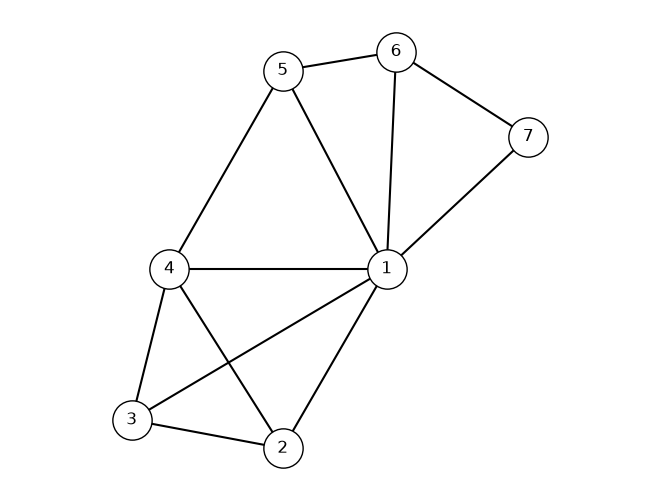

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Preserve node/qubit order: q0 -> node 1, ..., q6 -> node 7
G.add_nodes_from(range(1, 8))

G.add_edges_from([
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
    (1, 7),
    (2, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
])

pos = {
    1: (0.0, 0.0),
    2: (-0.55, -0.95),
    3: (-1.35, -0.80),
    4: (-1.15, 0.0),
    5: (-0.55, 1.05),
    6: (0.05, 1.15),
    7: (0.75, 0.70),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    edgecolors="black",
    node_size=800,
    width=1.5,
)

plt.axis("equal")
plt.show()

In [3]:
problem_kind = "mis"
initial_angle = np.pi / 3

problem    = MIS_MVC_Problem(G, problem_kind=problem_kind)
init_state = MIS_MVC_InitialState(G, problem_kind=problem_kind, angle=initial_angle, phase_correct=True)
# multi_angle=False: one shared β per layer → vanilla QAOA structure,
# which is required by the Fourier initializer.
lx_mixer   = VertexSubsetLXMixer(G, problem_kind=problem_kind, multi_angle=False)

grover_mixer = Grover(init_state)



objmin, objmax = problem.objective_bounds()
print(f"Optimal MIS size: {objmax}")


Optimal MIS size: 3.0


## Shared settings


In [4]:
backend    = AerSimulator()
shots      = 1024
maxdepth   = 10
angles_spec = {"gamma": [0, 2 * np.pi, 10], "beta": [0, 2*np.pi, 10]}


## Define one QAOA instance per initializer


In [5]:
def make_qaoa(init):
    return QAOA(
        problem=problem,
        mixer=grover_mixer,
        initialstate=init_state,
        backend=backend,
        shots=shots,
        initializer=init,
    )

configs = {
    "Interp":      make_qaoa(initializers.Interp()),
    "LayerGrid":   make_qaoa(initializers.LayerGrid(
                       gamma_values=[0, 2*np.pi, 10],
                       beta_values=[0, np.pi, 10],
                   )),
    "LinearRamp":  make_qaoa(initializers.LinearRamp()),
    "TQA":         make_qaoa(initializers.TQA()),
    "Random":      make_qaoa(initializers.Random(seed=42, n_candidates=100)),
    "FixedAngles": make_qaoa(initializers.FixedAngles(np.zeros(2))),  # all-zero start
    "Fourier":     make_qaoa(initializers.Fourier()),
}
print("Initializers to compare:", list(configs.keys()))


Initializers to compare: ['Interp', 'LayerGrid', 'LinearRamp', 'TQA', 'Random', 'FixedAngles', 'Fourier']


## Run optimization for each initializer


In [6]:
results = {}
for name, qaoa in configs.items():
    print(f"Running {name}...", end=" ", flush=True)
    qaoa.optimize(depth=maxdepth, angles=angles_spec)
    results[name] = [qaoa.get_energy(d) for d in range(1, maxdepth + 1)]
    print(f"done (depth-{maxdepth} energy: {results[name][-1]:.3f})")


Running Interp... 2026-09-01 16:03:24 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-09-01 16:03:25 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-09-01 16:03:25 [info     ] circuits: 100                  file=qaoa.qaoa func=sample_cost_landscape
2026-09-01 16:03:25 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-09-01 16:03:29 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-09-01 16:03:29 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-09-01 16:03:30 [info     ] energy(depth 1) = -2.0996093750000004 file=qaoa.qaoa func=optimize
2026-09-01 16:03:33 [info     ] energy(depth 2) = -2.251953125 file=qaoa.qaoa func=optimize
2026-09-01 16:03:39 [info     ] energy(depth 3) = -2.669921875 file=qaoa.qaoa func=optimize
2026-09-01 16:03:48 [info     ] energy(depth 4) = 

## Compare: expected energy vs depth


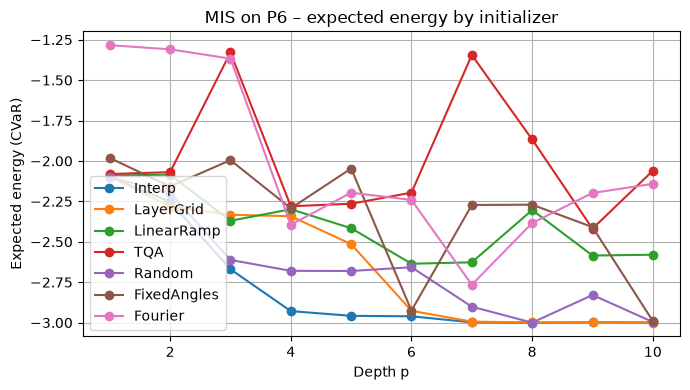

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, energies in results.items():
    ax.plot(range(1, maxdepth + 1), energies, marker='o', label=name)

ax.set_xlabel("Depth p")
ax.set_ylabel("Expected energy (CVaR)")
ax.set_title("MIS on P6 – expected energy by initializer")
ax.legend(loc="lower left")
ax.grid(True)
plt.tight_layout()
plt.show()


## Compare: approximation ratio vs depth


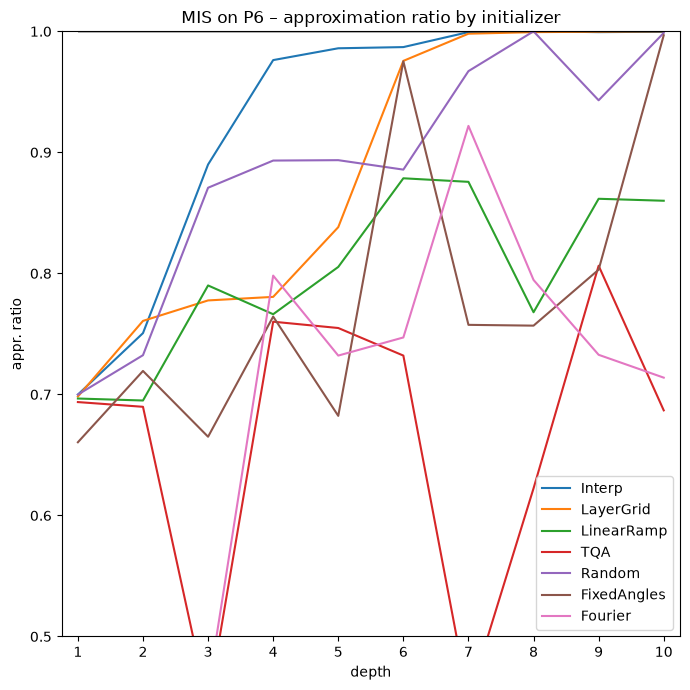

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, qaoa in configs.items():
    utils.plot_ApproximationRatio(
        qaoa, maxdepth, objmin, objmax,
        label=name,
        fig=fig,
    )

ax.set_title("MIS on P6 – approximation ratio by initializer")
ax.legend(loc="lower right")
ax.set_ylim(0.5,1)
plt.tight_layout()
plt.show()
